In [68]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jatan2007/negative-cyclone-samples")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/jatan2007/negative-cyclone-samples


In [69]:
import os
import cv2
from pathlib import Path
from tqdm import tqdm

In [70]:
# Dataset path
INPUT_DIR = Path("/kaggle/input/datasets/jatan2007/negative-cyclone-samples/negative samples")

# Output directories
OUTPUT_IMG_DIR = Path("/kaggle/working/processed_negative/images")
OUTPUT_LABEL_DIR = Path("/kaggle/working/processed_negative/labels")

OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LABEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640

In [71]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_files = []

for ext in image_extensions:
    image_files.extend(INPUT_DIR.rglob(f"*{ext}"))
    image_files.extend(INPUT_DIR.rglob(f"*{ext.upper()}"))

print(f"Total Images Found: {len(image_files)}")

Total Images Found: 1000


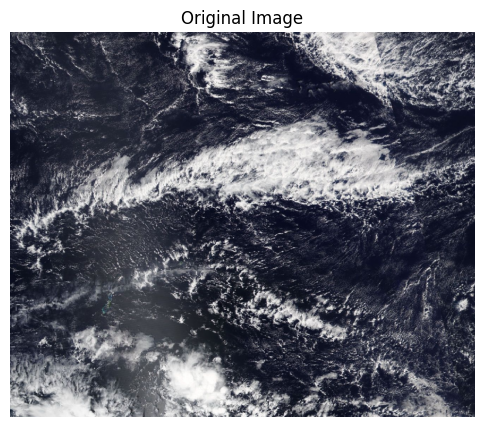

In [72]:
import matplotlib.pyplot as plt

sample = cv2.imread(str(image_files[0]))
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(sample)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [73]:
import numpy as np

counter = 1

for img_path in tqdm(sorted(image_files)):

    img = cv2.imread(str(img_path))

    if img is None:
        print(f"Skipping {img_path}")
        continue

    h, w = img.shape[:2]

    scale = min(IMG_SIZE / w, IMG_SIZE / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.full((IMG_SIZE, IMG_SIZE, 3), 114, dtype=np.uint8)

    x_offset = (IMG_SIZE - new_w) // 2
    y_offset = (IMG_SIZE - new_h) // 2

    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    gray = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    new_name = f"negative_{counter:06d}.jpg"

    save_path = OUTPUT_IMG_DIR / new_name

    cv2.imwrite(str(save_path), gray)

    counter += 1

print(f"Processed {counter-1} images.")

100%|██████████| 1000/1000 [00:34<00:00, 28.57it/s]

Processed 1000 images.


In [74]:
for img_path in OUTPUT_IMG_DIR.glob("*.jpg"):

    label_path = OUTPUT_LABEL_DIR / f"{img_path.stem}.txt"

    # Create empty file
    label_path.touch()

print(f"Created {len(list(OUTPUT_LABEL_DIR.glob('*.txt')))} label files.")

Created 1000 label files.


In [75]:
print("First 10 processed images:\n")

for file in sorted(OUTPUT_IMG_DIR.iterdir())[:10]:
    print(file.name)

First 10 processed images:

negative_000001.jpg
negative_000002.jpg
negative_000003.jpg
negative_000004.jpg
negative_000005.jpg
negative_000006.jpg
negative_000007.jpg
negative_000008.jpg
negative_000009.jpg
negative_000010.jpg


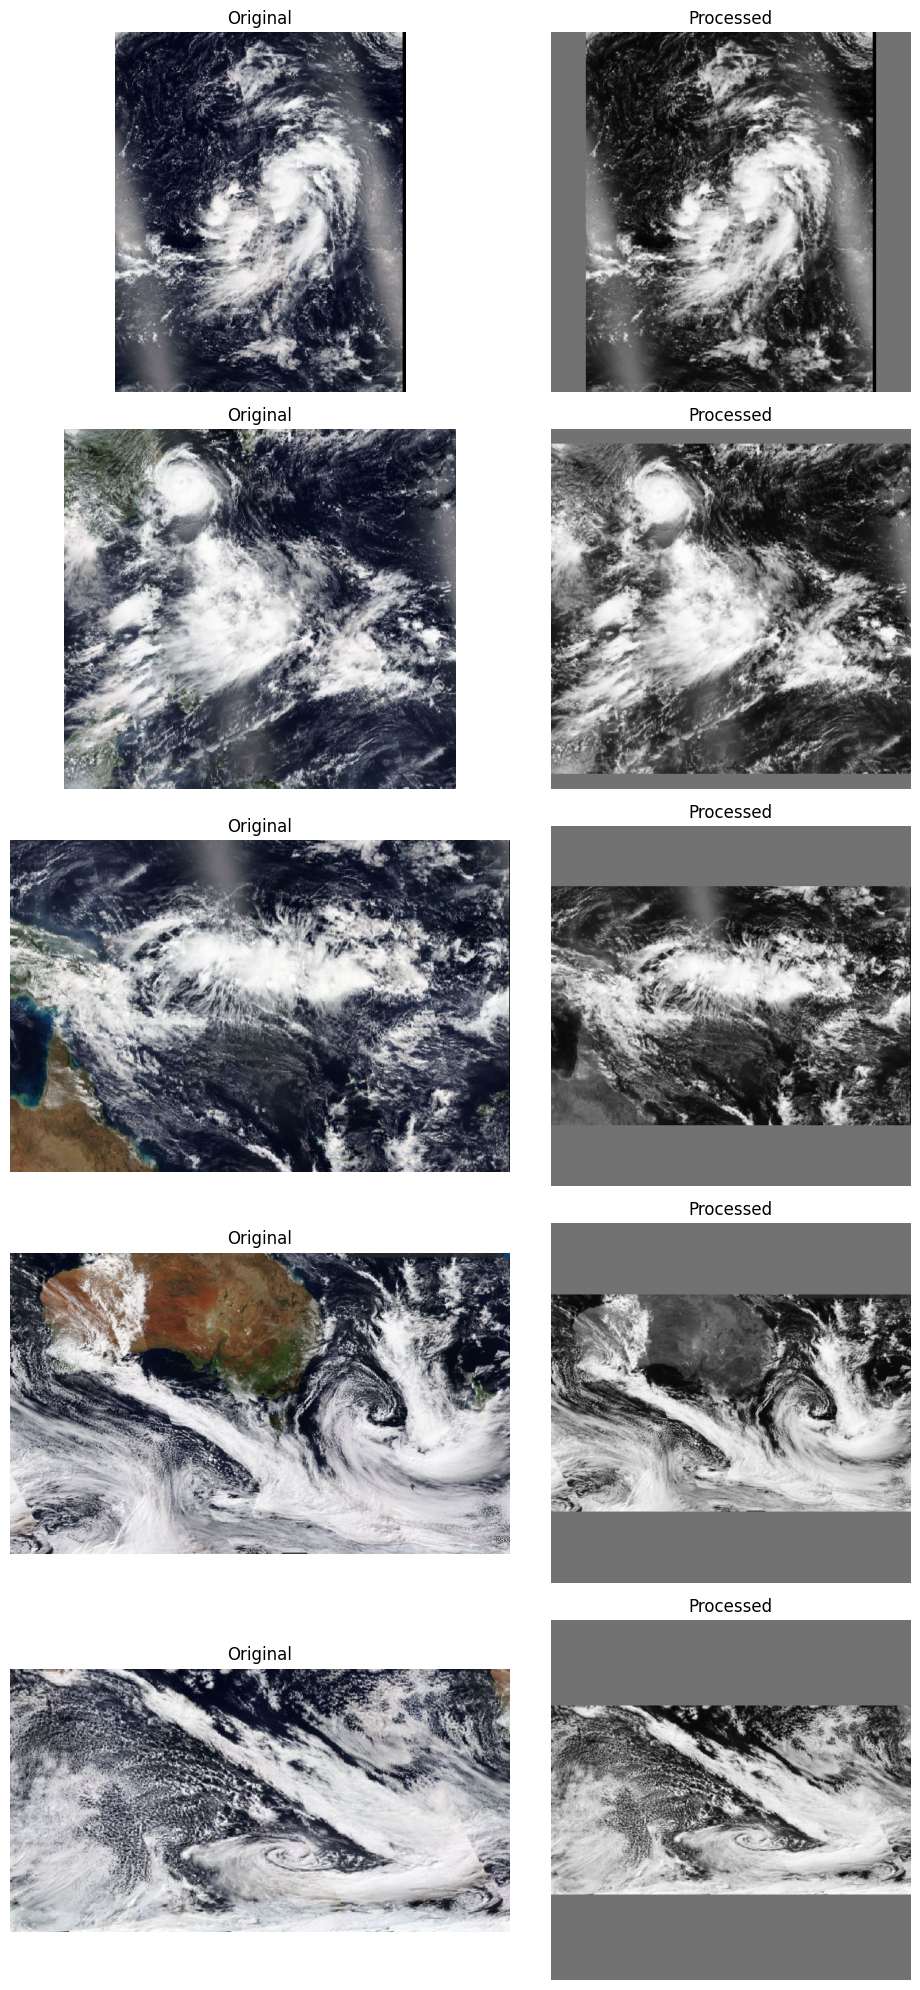

Comparison image saved to:
/kaggle/working/original_vs_processed.png


In [76]:
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Original images
original_files = sorted(image_files)

# Processed folder
processed_dir = Path("/kaggle/working/processed_negative/images")

n = 5

fig = plt.figure(figsize=(10, 4 * n))

for i in range(n):
    # Original
    orig = cv2.imread(str(original_files[i]))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    # Processed
    proc_path = processed_dir / f"negative_{i+1:06d}.jpg"
    proc = cv2.imread(str(proc_path))
    proc = cv2.cvtColor(proc, cv2.COLOR_BGR2RGB)

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(proc)
    plt.title("Processed")
    plt.axis("off")

plt.tight_layout()

# Save comparison image
save_path = "/kaggle/working/original_vs_processed.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Comparison image saved to:\n{save_path}")

In [77]:
import random

In [78]:
TEST_IMAGES = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/images")
TEST_LABELS = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/labels")

VAL_IMAGES = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_val/val/images")
VAL_LABELS = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_val/val/labels")

OUTPUT_DIR = Path("/kaggle/working/processed_positive")

OUTPUT_IMG_DIR = OUTPUT_DIR / "images"
OUTPUT_LABEL_DIR = OUTPUT_DIR / "labels"

OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LABEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640
TARGET_IMAGES = 5000

In [79]:
from pathlib import Path

TEST_IMAGES = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/images")
TEST_LABELS = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/labels")

VAL_IMAGES = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_val/val/images")
VAL_LABELS = Path("/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_val/val/labels")

print("Test Images :", TEST_IMAGES.exists())
print("Test Labels :", TEST_LABELS.exists())
print("Val Images  :", VAL_IMAGES.exists())
print("Val Labels  :", VAL_LABELS.exists())

Test Images : True
Test Labels : True
Val Images  : True
Val Labels  : True


In [80]:
image_extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

test_images = []
val_images = []

for ext in image_extensions:
    test_images.extend(TEST_IMAGES.glob(ext))
    val_images.extend(VAL_IMAGES.glob(ext))

print(f"Test Images : {len(test_images)}")
print(f"Validation Images : {len(val_images)}")

print("\nFirst 5 Test Images:")
for img in test_images[:5]:
    print(img.name)

print("\nFirst 5 Validation Images:")
for img in val_images[:5]:
    print(img.name)

Test Images : 2503
Validation Images : 2399

First 5 Test Images:
10NOV2013_0000_og.jpg
04MAY2019_1315_og.jpg
28APR2019_0400_og.jpg
28APR2019_1330_og.jpg
27APR2019_0445_og.jpg

First 5 Validation Images:
08OCT2018_2045_og.jpg
07OCT2018_2100_og.jpg
27OCT2019_2345_og.jpg
28OCT2019_0900_og.jpg
09OCT2018_0645_og.jpg


In [81]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/processed_positive")

OUTPUT_IMG_DIR = OUTPUT_DIR / "images"
OUTPUT_LABEL_DIR = OUTPUT_DIR / "labels"

OUTPUT_IMG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LABEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640

print(OUTPUT_IMG_DIR)
print(OUTPUT_LABEL_DIR)

/kaggle/working/processed_positive/images
/kaggle/working/processed_positive/labels


In [82]:
print("Test label files:", len(list(TEST_LABELS.glob("*.txt"))))
print("Validation label files:", len(list(VAL_LABELS.glob("*.txt"))))

print("\nSample image:", test_images[0].name)
print("Expected label:", test_images[0].stem + ".txt")

expected = TEST_LABELS / (test_images[0].stem + ".txt")
print("Exists:", expected.exists())
print("Full path:", expected)

Test label files: 2503
Validation label files: 2399

Sample image: 10NOV2013_0000_og.jpg
Expected label: 10NOV2013_0000_og.txt
Exists: True
Full path: /kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/labels/10NOV2013_0000_og.txt


In [83]:
pairs = []

for img_path in test_images:
    label_path = TEST_LABELS / (img_path.stem + ".txt")
    pairs.append((img_path, label_path))

for img_path in val_images:
    label_path = VAL_LABELS / (img_path.stem + ".txt")
    pairs.append((img_path, label_path))

print("Total pairs:", len(pairs))
print("First pair:", pairs[0])

Total pairs: 4902
First pair: (PosixPath('/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/images/10NOV2013_0000_og.jpg'), PosixPath('/kaggle/input/datasets/punitkashyap2007/cyclone-detection-dataset/Cyclone_detection_test/test/labels/10NOV2013_0000_og.txt'))


In [84]:
counter = 1

for img_path, label_path in tqdm(pairs):

    img = cv2.imread(str(img_path))

    if img is None:
        continue

    h, w = img.shape[:2]

    scale = min(IMG_SIZE / w, IMG_SIZE / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    x_offset = (IMG_SIZE - new_w) // 2
    y_offset = (IMG_SIZE - new_h) // 2

    canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    new_name = f"positive_{counter:06d}"

    cv2.imwrite(
        str(OUTPUT_IMG_DIR / f"{new_name}.jpg"),
        canvas
    )

    updated_labels = []

    with open(label_path, "r") as f:

        for line in f:

            cls, xc, yc, bw, bh = map(float, line.strip().split())

            xc *= w
            yc *= h
            bw *= w
            bh *= h

            xc = xc * scale + x_offset
            yc = yc * scale + y_offset

            bw *= scale
            bh *= scale

            xc /= IMG_SIZE
            yc /= IMG_SIZE
            bw /= IMG_SIZE
            bh /= IMG_SIZE

            updated_labels.append(
                f"{int(cls)} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"
            )

    with open(OUTPUT_LABEL_DIR / f"{new_name}.txt", "w") as f:
        f.write("\n".join(updated_labels))

    counter += 1

print(f"Processed {counter-1} images.")

100%|██████████| 4902/4902 [03:02<00:00, 26.80it/s]

Processed 4902 images.


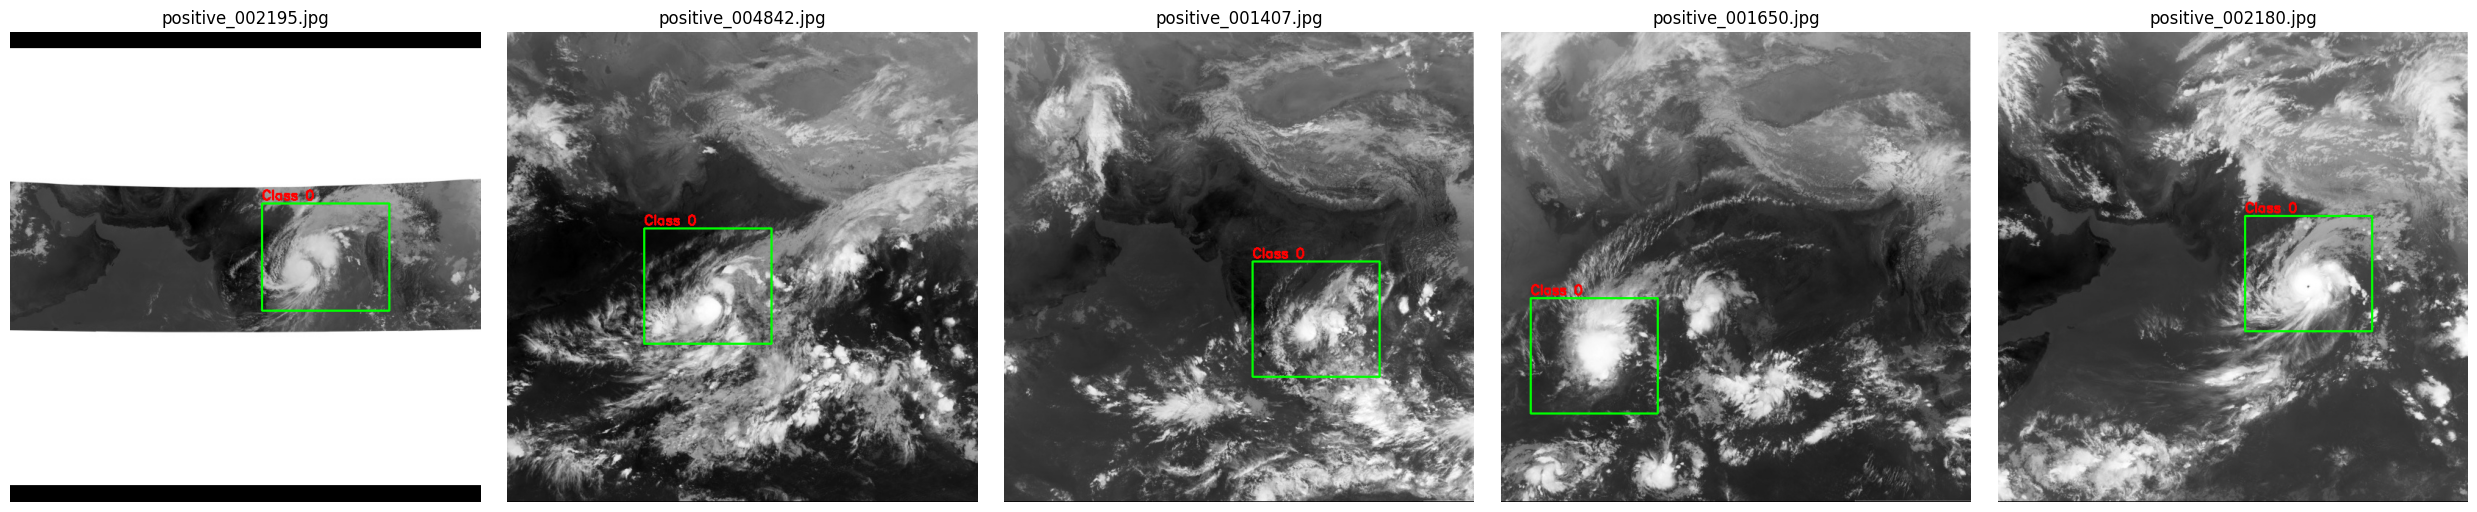

In [85]:
samples = random.sample(list(OUTPUT_IMG_DIR.glob("*.jpg")), 5)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, img_path in zip(axes, samples):

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = OUTPUT_LABEL_DIR / (img_path.stem + ".txt")

    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            cv2.putText(
                img,
                f"Class {int(cls)}",
                (x1, max(20, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2,
            )

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [86]:
random.seed(42)

POS_DIR = Path("/kaggle/working/processed_positive")
NEG_DIR = Path("/kaggle/working/processed_negative")

FINAL_DIR = Path("/kaggle/working/final_dataset")

for folder in [
    FINAL_DIR/"images/train",
    FINAL_DIR/"images/val",
    FINAL_DIR/"images/test",
    FINAL_DIR/"labels/train",
    FINAL_DIR/"labels/val",
    FINAL_DIR/"labels/test"
]:
    folder.mkdir(parents=True, exist_ok=True)

In [87]:
dataset = []

for img in (POS_DIR/"images").glob("*.jpg"):
    label = POS_DIR/"labels"/f"{img.stem}.txt"

    if label.exists():
        dataset.append((img, label))

for img in (NEG_DIR/"images").glob("*.jpg"):
    label = NEG_DIR/"labels"/f"{img.stem}.txt"

    if label.exists():
        dataset.append((img, label))

print("Total Images :", len(dataset))

Total Images : 5902


In [88]:
random.shuffle(dataset)

total = len(dataset)

train_split = int(0.8 * total)
val_split = int(0.9 * total)

train_set = dataset[:train_split]
val_set = dataset[train_split:val_split]
test_set = dataset[val_split:]

print(len(train_set))
print(len(val_set))
print(len(test_set))

4721
590
591


In [89]:
def copy_dataset(data, split):

    for img_path, label_path in tqdm(data):

        shutil.copy2(
            img_path,
            FINAL_DIR/"images"/split/img_path.name
        )

        shutil.copy2(
            label_path,
            FINAL_DIR/"labels"/split/label_path.name
        )

copy_dataset(train_set,"train")
copy_dataset(val_set,"val")
copy_dataset(test_set,"test")

100%|██████████| 591/591 [00:00<00:00, 1765.99it/s]


In [90]:
for split in ["train","val","test"]:

    print(split.upper())

    print(
        "Images :",
        len(list((FINAL_DIR/"images"/split).glob("*.jpg")))
    )

    print(
        "Labels :",
        len(list((FINAL_DIR/"labels"/split).glob("*.txt")))
    )

    print()

TRAIN
Images : 4721
Labels : 4721

VAL
Images : 590
Labels : 590

TEST
Images : 591
Labels : 591



In [91]:
yaml_content = """
path: /kaggle/working/final_dataset

train: images/train
val: images/val
test: images/test

nc: 1

names:
  0: cyclone
"""

with open("/kaggle/working/final_dataset/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml created!")

data.yaml created!


In [92]:
positive = 0
negative = 0

for lbl in (FINAL_DIR/"labels").rglob("*.txt"):

    if lbl.stat().st_size == 0:
        negative += 1
    else:
        positive += 1

print("Positive :", positive)
print("Negative :", negative)

Positive : 4902
Negative : 1000


In [93]:
import os

zip_file = "/kaggle/working/final_dataset.zip"

if os.path.exists(zip_file):
    os.remove(zip_file)
    print("Deleted successfully!")
else:
    print("File not found.")

Deleted successfully!


In [94]:
import shutil

shutil.make_archive(
    "/kaggle/working/final_dataset",
    "zip",
    "/kaggle/working/final_dataset"
)

print("ZIP created successfully!")

ZIP created successfully!


In [95]:
import os

print(os.path.exists("/kaggle/working/final_dataset.zip"))
print(os.path.getsize("/kaggle/working/final_dataset.zip") / (1024**2), "MB")

True
812.8198852539062 MB


In [96]:
from IPython.display import FileLink

FileLink("/kaggle/working/final_dataset.zip")

/kaggle/working/final_dataset.zip

In [97]:
from pathlib import Path

zip_path = Path("/kaggle/working/final_dataset.zip")

print(zip_path.exists())

if zip_path.exists():
    print(f"Size: {zip_path.stat().st_size / (1024**3):.2f} GB")

True
Size: 0.79 GB
